# Published-image transfer case: BBBC013 channel roles

BBBC013 provides paired GFP and DNA images from a 96-well U2OS assay. This CC
BY 3.0 exercise asks how channel roles and region definitions affect a
measurement. It does not reproduce a dose-response result or establish protein
translocation.

Source: https://bbbc.broadinstitute.org/BBBC013

## Learning objectives

1. pair channels using shared image metadata rather than file order;
2. use the DNA channel to define nuclear regions and GFP to measure signal;
3. test how a perinuclear-ring definition changes a derived ratio;
4. preserve the distinction between wells, images, objects, and replicates.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

from src.multichannel import nuclear_perinuclear_summary
from src.segmentation import load_grayscale_image
from src.sensitivity import SensitivityConfig, segment_with_config

DATA = ROOT / "data" / "external" / "BBBC013" / "BBBC013_v1_images_bmp"
if not DATA.exists():
    raise FileNotFoundError("Run: python scripts/download_bbbc013.py")

## Pair channels explicitly

Three wells are selected only as varied teaching images. They are not treated
as replicates or used for treatment inference. Channel 1 is GFP signal; Channel
2 is DNA. The shared numeric/row/column suffix is the pairing key.

In [2]:
pair_keys = ["02-A-02", "43-D-07", "79-G-07"]
records = []
for key in pair_keys:
    gfp = load_grayscale_image(DATA / f"Channel1-{key}.BMP")
    dna = load_grayscale_image(DATA / f"Channel2-{key}.BMP")
    records.append({"well_key": key, "gfp": gfp, "dna": dna})

pd.DataFrame([{
    "well_key": row["well_key"], "shape": str(row["gfp"].shape),
    "gfp_dtype": str(row["gfp"].dtype), "dna_dtype": str(row["dna"].dtype),
    "paired_shapes_match": row["gfp"].shape == row["dna"].shape,
} for row in records])

,well_key,shape,gfp_dtype,dna_dtype,paired_shapes_match
0,02-A-02,"(640, 640)",uint8,uint8,True
1,43-D-07,"(640, 640)",uint8,uint8,True
2,79-G-07,"(640, 640)",uint8,uint8,True


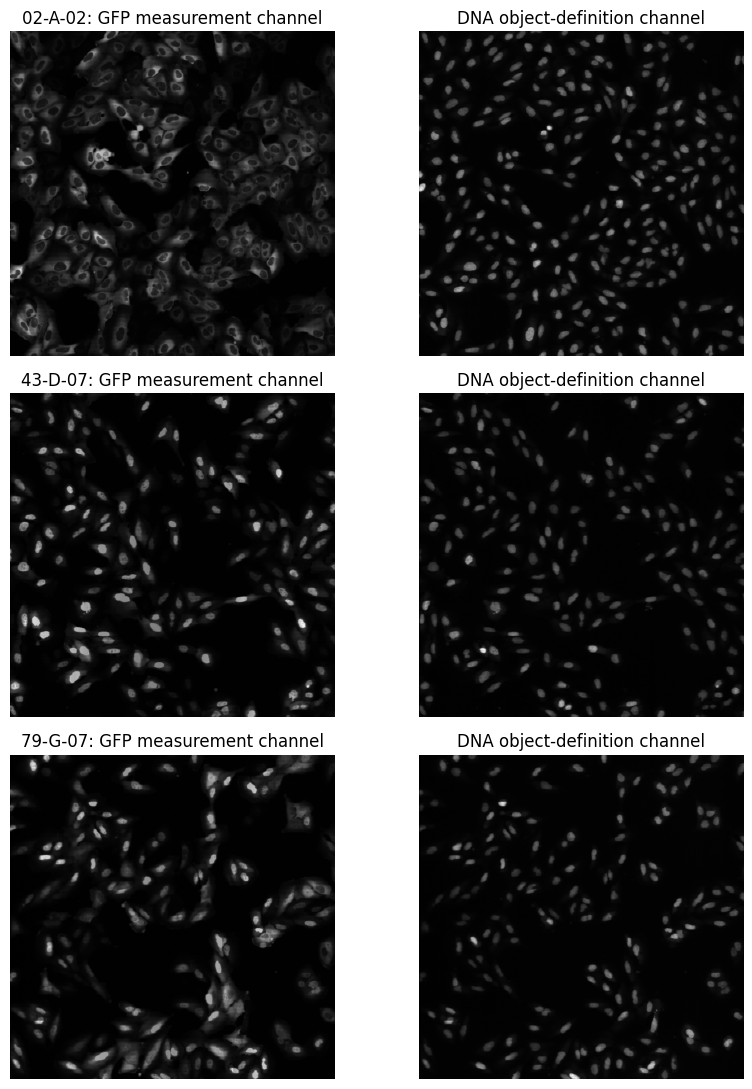

In [3]:
fig, axes = plt.subplots(len(records), 2, figsize=(9, 11))
for index, row in enumerate(records):
    axes[index, 0].imshow(row["gfp"], cmap="gray")
    axes[index, 0].set_title(f'{row["well_key"]}: GFP measurement channel')
    axes[index, 1].imshow(row["dna"], cmap="gray")
    axes[index, 1].set_title("DNA object-definition channel")
    for axis in axes[index]:
        axis.axis("off")
plt.tight_layout()

## Sensitivity to the region definition

Nuclei are segmented once from DNA using an illustrative Otsu configuration.
GFP is then summarized inside the nuclear mask and in exterior rings of 3, 8,
and 15 pixels. The ring is an operational convenience—not a validated whole-
cell or cytoplasmic boundary.

In [4]:
config = SensitivityConfig("dna_otsu", 1.0, 20, "otsu", None, 20, 1)
ring_radii = [3, 8, 15]
results = []
labels_by_well = {}

for row in records:
    _, _, labels, threshold = segment_with_config(row["dna"], config)
    labels_by_well[row["well_key"]] = labels
    for radius in ring_radii:
        summary = nuclear_perinuclear_summary(row["gfp"], labels, radius)
        results.append({"well_key": row["well_key"], "ring_radius_px": radius,
                        "dna_threshold": threshold,
                        "segmented_objects": int(labels.max()), **summary})

results_df = pd.DataFrame(results)
results_df.round(4)

,well_key,ring_radius_px,dna_threshold,segmented_objects,nuclear_mean_signal,perinuclear_mean_signal,nuclear_to_perinuclear_ratio,nuclear_fraction,perinuclear_fraction
0,02-A-02,3,0.1582,247,27.8085,41.0144,0.6780,0.1142,0.1020
1,02-A-02,8,0.1582,247,27.8085,32.7655,0.8487,0.1142,0.3235
2,02-A-02,15,0.1582,247,27.8085,25.2963,1.0993,0.1142,0.6211
3,43-D-07,3,0.1270,180,82.6470,28.4083,2.9093,0.0828,0.0736
4,43-D-07,8,0.1270,180,82.6470,17.7019,4.6688,0.0828,0.2371
5,43-D-07,15,0.1270,180,82.6470,12.3601,6.6866,0.0828,0.4810
6,79-G-07,3,0.1465,159,84.3835,38.1241,2.2134,0.0677,0.0638
7,79-G-07,8,0.1465,159,84.3835,25.5944,3.2970,0.0677,0.2053
8,79-G-07,15,0.1465,159,84.3835,17.7422,4.7561,0.0677,0.4206


In [5]:
pivot = results_df.pivot(
    index="well_key", columns="ring_radius_px",
    values="nuclear_to_perinuclear_ratio"
)
pivot.columns = [f"ratio_ring_{radius}px" for radius in pivot.columns]
pivot.round(4)

,ratio_ring_3px,ratio_ring_8px,ratio_ring_15px
well_key,,,
02-A-02,0.6780,0.8487,1.0993
43-D-07,2.9093,4.6688,6.6866
79-G-07,2.2134,3.2970,4.7561


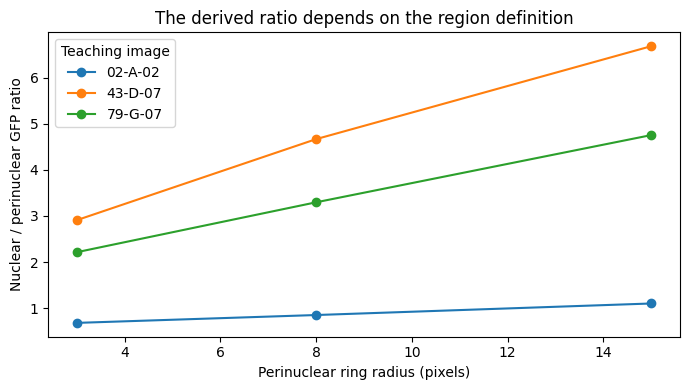

In [6]:
fig, axis = plt.subplots(figsize=(7, 4))
for well_key, group in results_df.groupby("well_key"):
    axis.plot(group["ring_radius_px"], group["nuclear_to_perinuclear_ratio"],
              marker="o", label=well_key)
axis.set(xlabel="Perinuclear ring radius (pixels)",
         ylabel="Nuclear / perinuclear GFP ratio",
         title="The derived ratio depends on the region definition")
axis.legend(title="Teaching image")
plt.tight_layout()

## Interpretation boundary

The defensible conclusion is that a multichannel measurement depends on both
channel assignment and the operational definition of the comparison region.
These three wells do not establish a treatment effect. A validated analysis
would need cell-boundary information or a justified cytoplasmic proxy,
plate-aware quality control, the full replicate structure, and a prespecified
statistical model.